# **Prédiction du prix de l’action NVIDIA Corporation par machine learning**

L’objectif de ce projet est de construire un modèle de machine learning capable de prédire l’évolution du prix de l’action NVIDIA Corporation (NVDA). Plus précisément, nous cherchons à identifier les facteurs financiers et de marché qui influencent la dynamique du titre et à utiliser ces informations pour anticiper ses variations futures.

Pour cela, nous construisons progressivement un jeu de données structuré qui servira de base à l’apprentissage du modèle. Cette base intègre à la fois des variables financières et des variables contextuelles susceptibles d’influencer l’évolution du prix de l’action NVIDIA Corporation.

Les variables financières incluent par exemple les indices de marché, les rendements ou les indicateurs de volatilité. Les variables contextuelles peuvent quant à elles refléter des facteurs plus larges tels que des événements macroéconomiques, géopolitiques ou spécifiques à l’entreprise, comme des annonces de résultats, des innovations technologiques ou des évolutions réglementaires.

**Installation des packages**


In [34]:
pip install yfinance pandas numpy pandas-datareader

**Importer des bibliothèques**

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **I — Chargement des données**

A. La première étape consiste à récupérer les données historiques du prix des differents variables à l’aide de la bibliothèque yfinance, qui permet d’accéder facilement aux données financières disponibles sur Yahoo Finance.

Définir la période

In [36]:
start = "2018-01-01"
end = "2026-01-01"

In [37]:
tickers = [
"NVDA",
"^GSPC",
"^IXIC",
"SOXX",
"AMD",
"TSM",
"INTC",
"^VXN",
"DX-Y.NYB",
"^TNX"
]

data = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]

[*********************100%***********************]  10 of 10 completed


In [38]:
data.head()

Ticker,AMD,DX-Y.NYB,INTC,NVDA,SOXX,TSM,^GSPC,^IXIC,^TNX,^VXN
Date,,,,,,,,,,
2018-01-02,10.98,91.849998,39.330376,4.928267,53.683517,33.848354,2695.810059,7006.899902,2.465,14.93
2018-01-03,11.55,92.160004,37.995583,5.252615,54.622246,34.417713,2713.060059,7065.529785,2.447,14.16
2018-01-04,12.12,91.849998,37.298813,5.280303,54.930023,34.236176,2723.989990,7077.910156,2.453,13.97
2018-01-05,11.88,91.949997,37.559052,5.325051,55.243958,35.036575,2743.149902,7136.560059,2.476,13.48
2018-01-08,12.28,92.330002,37.559052,5.488211,55.677921,35.020077,2747.709961,7157.390137,2.480,13.84


Renommer les colonnes

In [39]:
data = data.rename(columns={
"NVDA": "NVDA",
"^GSPC": "SP500",
"^IXIC": "NASDAQ",
"SOXX": "SOXX",
"AMD": "AMD",
"TSM": "TSMC",
"INTC": "INTC",
"^VXN": "VXN",
"DX-Y.NYB": "DXY",
"^TNX": "US10Y"
})

### **II — Chargement des variables CPI, Taux FED, GPR, Events et Covid**

In [40]:
from google.colab import files
uploaded = files.upload()

In [41]:
from google.colab import files
uploaded = files.upload()

Saving CPIAUCSL.csv to CPIAUCSL.csv
Saving FEDFUNDS.csv to FEDFUNDS.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving FEDFUNDS.csv to FEDFUNDS.csv


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
CPI = pd.read_csv("CPIAUCSL.csv")

CPI = CPI.rename(columns={"observation_date" : "Date", "CPIAUCSL" : "CPI"})
CPI["Date"] = pd.to_datetime(CPI["Date"])
CPI = CPI.set_index("Date")
CPI_daily = CPI.resample("D").ffill()
CPI_daily.head()

# Ajouter CPI et CPI_pct au dataset existant
data = data.join(CPI_daily[['CPI']], how='left')

In [44]:
fed_rate = pd.read_csv("FEDFUNDS.csv")

fed_rate = fed_rate.rename(columns={"observation_date" : "Date", "FEDFUNDS" : "Taux_FED"})
fed_rate["Date"] = pd.to_datetime(fed_rate["Date"])  #conversion les dates en format date
fed_rate = fed_rate.set_index("Date") # data comme index
fed_daily = fed_rate.resample("D").ffill() #forward daily
fed_daily.head()

# Ajouter CPI et CPI_pct au dataset existant
data = data.join(fed_daily[['Taux_FED']], how='left')

In [46]:
df_GPR = pd.read_csv("GPR_DAILY.csv")

df_GPR = df_GPR.rename(columns={"date" : "Date", "GPRD" : "GPRD"})
df_GPR["Date"] = pd.to_datetime(df_GPR["Date"], dayfirst=True)
df_GPR = df_GPR.set_index("Date") # data comme index

start_date = data.index.min()
end_date   = data.index.max()

df_GPR = df_GPR[(df_GPR.index >= start_date) & (df_GPR.index <= end_date)]
df_GPR = df_GPR[["GPRD"]]
df_GPR.head()

# Ajouter GPRD
data = data.join(df_GPR[['GPRD']], how='left')

data["GPRD"] = data["GPRD"].astype(str).str.replace(",", ".").astype(float)

FileNotFoundError: [Errno 2] No such file or directory: 'GPR_DAILY.csv'

In [ ]:
df_TRADEWAR = pd.read_csv("TRADE_WAR_TARIFFS.csv")

df_TRADEWAR = df_TRADEWAR.rename(columns={
    "Date": "Date",
    "US tariffs on Chinese exports": "US_Tariffs",
    "Chinese tariffs on US exports": "China_Tariffs"
})
df_TRADEWAR["Date"] = pd.to_datetime(df_TRADEWAR["Date"], format='%d-%b-%y', errors='coerce')
df_TRADEWAR = df_TRADEWAR.dropna(subset=['Date']).drop_duplicates(subset='Date')
df_TRADEWAR = df_TRADEWAR.set_index("Date").sort_index() # mise en index

df_TRADEWAR["US_Tariffs"] = df_TRADEWAR["US_Tariffs"].str.replace(',', '.')
df_TRADEWAR["China_Tariffs"] = df_TRADEWAR["China_Tariffs"].str.replace(',', '.') # remplace virgules par des points

df_TRADEWAR["US_Tariffs"] = pd.to_numeric(df_TRADEWAR["US_Tariffs"], errors='coerce')
df_TRADEWAR["China_Tariffs"] = pd.to_numeric(df_TRADEWAR["China_Tariffs"], errors='coerce') #conversion en numérique

data["US_Tariffs"] = data.index.map(df_TRADEWAR["US_Tariffs"])
data["China_Tariffs"] = data.index.map(df_TRADEWAR["China_Tariffs"])

data["US_Tariffs"] = data["US_Tariffs"].ffill()
data["China_Tariffs"] = data["China_Tariffs"].ffill() #dernière valeur connue

data["US_Tariffs"] = data["US_Tariffs"].bfill()
data["China_Tariffs"] = data["China_Tariffs"].bfill() #les dates avant le premier événement

In [ ]:
covid_start = '2020-03-01'
covid_end = '2021-12-31'

data['COVID_period'] = 0
data.loc[(data.index >= covid_start) & (data.index <= covid_end), 'COVID_period'] = 1

In [ ]:
data.to_excel("dataset_nvda_ml.xlsx")

data.reset_index().to_excel("dataset_nvda_ml.xlsx", index=False)

### **III— Analyse exploratoire et statistiques descriptives**

Une fois les données récupérées, nous réalisons une analyse exploratoire afin de comprendre ses principales caractéristiques statistiques (moyenne, médiane, écart-type, minimum, maximum). Cette étape permet de détecter la variabilité du prix et d’éventuelles périodes de forte volatilité, et de vérifier la qualité des données avant de construire un modèle de machine learning.

**A. Quelques statistiques descriptives**

In [ ]:
data.head()

,AMD,DXY,INTC,NVDA,SOXX,TSMC,SP500,NASDAQ,US10Y,VXN,US_Tariffs,China_Tariffs,GPRD,CPI,Taux_FED,COVID_period
Date,,,,,,,,,,,,,,,,
2018-01-02,10.98,91.849998,39.330379,4.928266,53.683502,33.848343,2695.810059,7006.899902,2.465,14.93,3.2,8.0,188.69,248.859,1.41,0
2018-01-03,11.55,92.160004,37.995586,5.252614,54.622250,34.417709,2713.060059,7065.529785,2.447,14.16,3.2,8.0,138.02,248.859,1.41,0
2018-01-04,12.12,91.849998,37.298801,5.280303,54.930027,34.236179,2723.989990,7077.910156,2.453,13.97,3.2,8.0,146.36,248.859,1.41,0
2018-01-05,11.88,91.949997,37.559055,5.325049,55.243969,35.036587,2743.149902,7136.560059,2.476,13.48,3.2,8.0,66.52,248.859,1.41,0
2018-01-08,12.28,92.330002,37.559055,5.488213,55.677940,35.020081,2747.709961,7157.390137,2.480,13.84,3.2,8.0,82.17,248.859,1.41,0


In [ ]:
#Statistiques descriptives
data.describe()

,AMD,DXY,INTC,NVDA,SOXX,TSMC,SP500,NASDAQ,US10Y,VXN,US_Tariffs,China_Tariffs,GPRD,CPI,Taux_FED,COVID_period
count,2011.000000,2013.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2013.000000,2013.000000,2013.000000,1990.000000,2013.000000,2013.000000
mean,89.697618,98.966692,39.186025,44.432855,136.646640,100.798216,4145.334404,12855.270523,2.845064,23.963232,20.571684,20.496026,125.902971,283.271596,2.562534,0.230999
std,53.313867,5.332065,10.350725,54.075979,66.179510,64.578039,1172.839708,4383.916180,1.259050,7.265103,11.492553,5.202914,59.139698,26.292119,1.955493,0.421576
min,9.530000,88.589996,18.129999,3.150397,45.163761,29.389709,2237.399902,6192.919922,0.499000,13.480000,3.200000,8.000000,9.490000,248.859000,0.050000,0.000000
25%,42.800001,95.139999,30.774776,6.481524,72.810776,46.784420,3004.994995,8517.810059,1.663000,18.740000,19.300000,21.100000,86.680000,257.042000,0.200000,0.000000
50%,87.900002,98.260002,41.223553,17.563023,133.795898,88.421692,4079.090088,12657.549805,2.913000,21.889999,19.300000,21.100000,117.680000,280.845000,2.330000,0.000000
75%,120.709999,103.430000,46.465105,49.532721,177.871323,118.746887,4772.290039,15602.379883,4.078000,27.840000,19.300000,21.200000,154.630000,308.741000,4.330000,0.000000
max,264.329987,114.110001,62.083332,207.017273,315.867188,309.305023,6932.049805,23958.470703,4.988000,80.080002,57.600000,32.600000,542.290000,326.031000,5.330000,1.000000


In [ ]:
# Vérifier les valeurs manquantes
print(data.isna().sum())

AMD               2
DXY               0
INTC              2
NVDA              2
SOXX              2
TSMC              2
SP500             2
NASDAQ            2
US10Y             2
VXN               2
US_Tariffs        0
China_Tariffs     0
GPRD              0
CPI              23
Taux_FED          0
COVID_period      0
dtype: int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2013 entries, 2018-01-02 to 2025-12-31
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AMD            2011 non-null   float64
 1   DXY            2013 non-null   float64
 2   INTC           2011 non-null   float64
 3   NVDA           2011 non-null   float64
 4   SOXX           2011 non-null   float64
 5   TSMC           2011 non-null   float64
 6   SP500          2011 non-null   float64
 7   NASDAQ         2011 non-null   float64
 8   US10Y          2011 non-null   float64
 9   VXN            2011 non-null   float64
 10  US_Tariffs     2013 non-null   float64
 11  China_Tariffs  2013 non-null   float64
 12  GPRD           2013 non-null   float64
 13  CPI            1990 non-null   float64
 14  Taux_FED       2013 non-null   float64
 15  COVID_period   2013 non-null   int64  
dtypes: float64(15), int64(1)
memory usage: 267.4 KB


**B. Variable cible**

La colonne NVDA constitue la variable cible principale de notre analyse. Elle représente le prix de l’action NVIDIA au cours du temps. Ce DataFrame sert de base pour l’analyse, et sera progressivement enrichi par l’ajout d’autres variables explicatives pertinentes, notamment des indicateurs macroéconomiques, financiers et sectoriels.

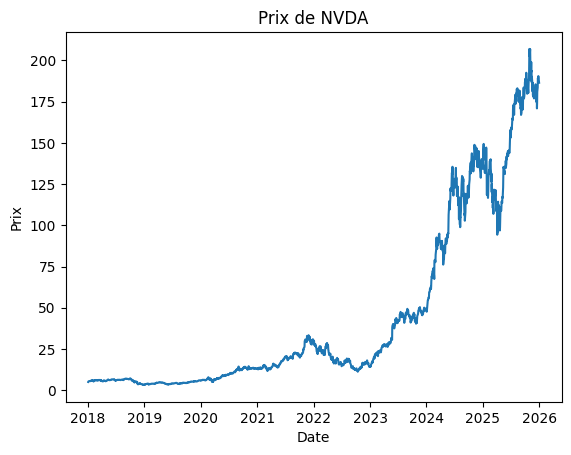

In [ ]:
import matplotlib.pyplot as plt

plt.plot(data.index, data["NVDA"])
plt.title("Prix de NVDA")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

### **IV- Contexte sectoriel et concurrentiel**

Pour analyser la performance de NVDA, nous enrichissons notre jeu de données avec des actions du secteur (AMD, TSMC), des indices de marché (NASDAQ, SOXX), et des variables macro-financières (VIX, taux d’intérêt FED, CPI, Dollar Index, rendement US10Y). L’objectif est de capturer à la fois les dynamiques propres au secteur, les tendances du marché et l’environnement économique pour améliorer la capacité prédictive du modèle.

**A. Action NVDA dans son contexte sectoriel**

Bénéficiant d'une position dominante sur le marché des processeurs graphiques (GPU), NVIDIA appartient au secteur des semi-conducteurs. Aujourd'hui, en pleine explosion grâce à l'IA et au calcul haute performance.

Ce marché se divise en trois segments principaux :

- **Fabless** (conception sans fabrication) : NVIDIA, AMD, Qualcomm, Broadcom.

- **Foundries** (fabrication pure) : TSMC (leader avec ~67% des parts), Samsung Foundry.

- **IDM** (intégrés, conception + fabrication) : Intel, qui perd toutefois du terrain face au modèle fabless-foundry.

Afin de mieux situer l'action NVDA dans son secteur, notre jeu de données intègre les cours boursiers des acteurs les plus pertinents (AMD, TSM, INTC).

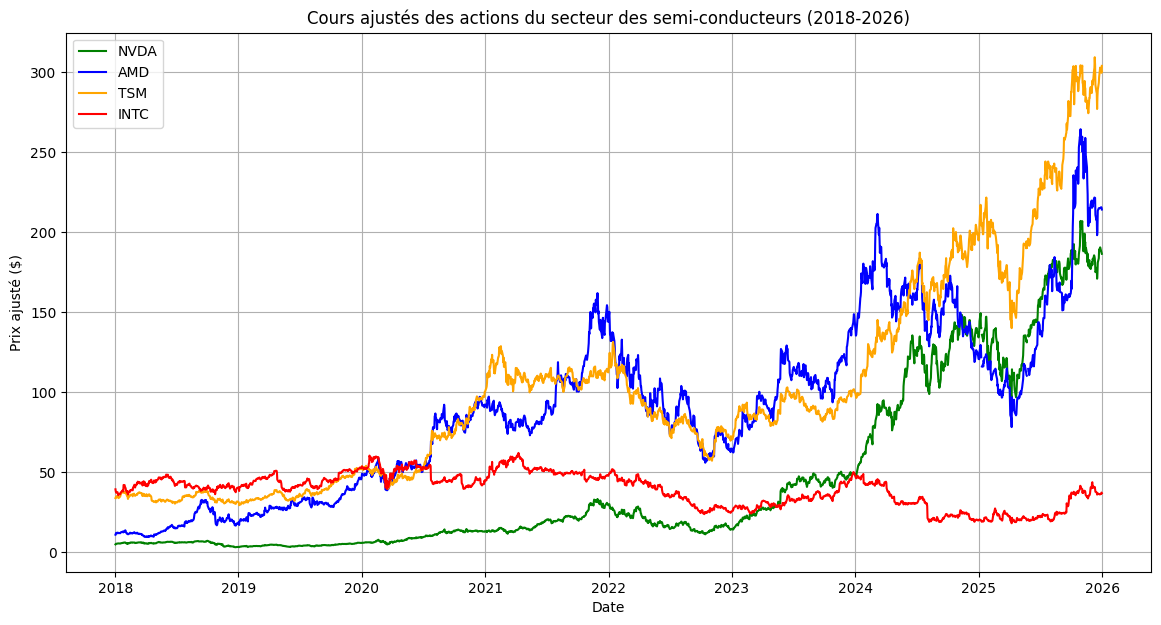

In [ ]:
# Tracer les cours ajustés de NVDA, AMD, TSM et INTC
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['NVDA'], label='NVDA', color='green')
plt.plot(data.index, data['AMD'],  label='AMD',  color='blue')
plt.plot(data.index, data['TSMC'],  label='TSM',  color='orange')
plt.plot(data.index, data['INTC'], label='INTC', color='red')

plt.title("Cours ajustés des actions du secteur des semi-conducteurs (2018-2026)")
plt.xlabel("Date")
plt.ylabel("Prix ajusté ($)")
plt.legend()
plt.grid(True)
plt.show()

**B. Indices de marché**

Pour évaluer précisément la performance de l'action NVDA, il est essentiel de la comparer aux indices sectoriels et de marché, qui reflètent les tendances globales et les dynamiques spécifiques du secteur des semi-conducteurs.

- S&P500: Indice boursier qui regroupe 500 des plus grandes entreprises cotées aux États-Unis. Il représente la performance globale du marché américain et inclut des sociétés de nombreux secteurs (technologie, santé, finance, etc.).
- IXIC: Indice qui regroupe toutes les entreprises cotées sur la bourse NASDAQ. Il est fortement orienté vers les entreprises technologiques (comme Apple, Microsoft, Nvidia), ce qui en fait un bon indicateur de la performance du secteur technologique.
- SOXX: ETF qui suit un indice du secteur des semi-conducteurs. Il reflète la performance des principales entreprises qui fabriquent des puces électroniques (comme Nvidia, AMD, Intel, Broadcom).

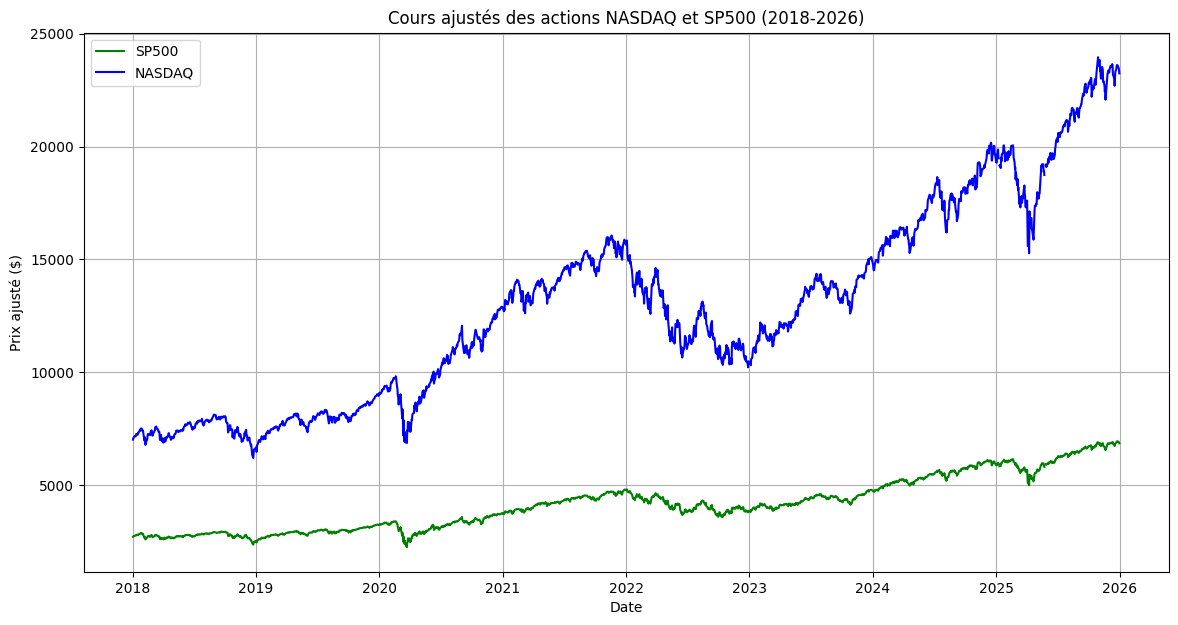

In [ ]:
# Tracer les cours ajustés de SP500 et NASDAQ
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['SP500'], label='SP500', color='green')
plt.plot(data.index, data['NASDAQ'],  label='NASDAQ',  color='blue')

plt.title("Cours ajustés des actions NASDAQ et SP500 (2018-2026)")
plt.xlabel("Date")
plt.ylabel("Prix ajusté ($)")
plt.legend()
plt.grid(True)
plt.show()

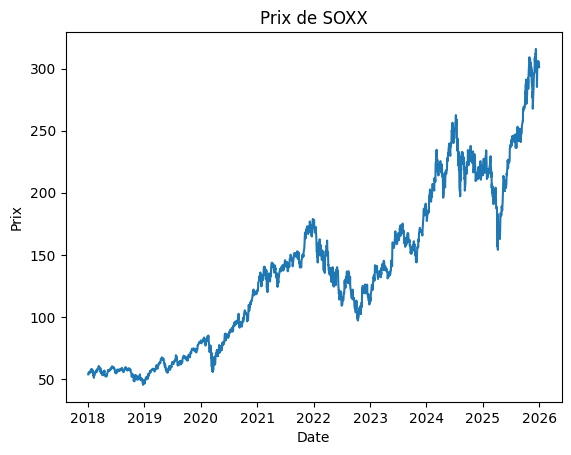

In [ ]:
plt.plot(data.index, data["SOXX"])
plt.title("Prix de SOXX")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

**C. Indices de volatilité / risque**

NVDA, comme beaucoup de titres technologiques, est sensible aux mouvements brusques du marché.

À ce titre, les indices de volatilité nous permettent de différencier les mouvements sectoriels normaux et les conditions de marché extrêmes.Calculer les returns

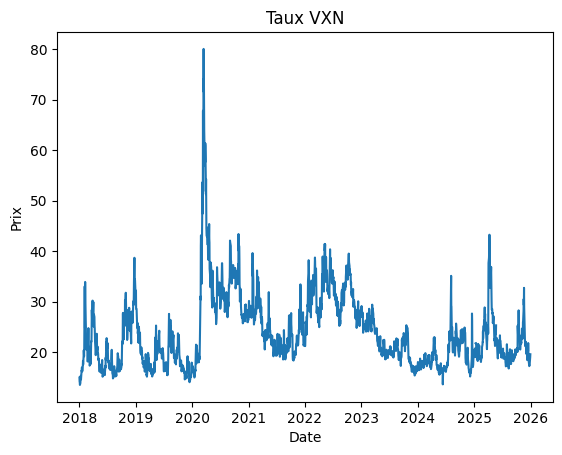

In [ ]:
plt.plot(data.index, data["VXN"])
plt.title("Taux VXN")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

### **V - Contexte macroéconomique, géopolitique et COVID**

**A. Taux de change / devise**

Les entreprises technologiques comme NVIDIA peuvent être sensibles aux fluctuations du dollar américain, notamment en raison de leur exposition aux revenus internationaux et aux effets sur leur compétitivité. Afin de prendre en compte cet aspect, nous intégrons l’indice DX-Y.NYB, qui correspond au U.S. Dollar Index (DXY). Cet indice mesure la valeur du dollar américain par rapport à un panier de devises majeures et permet de capturer les conditions financières internationales susceptibles d’influencer les marchés actions.

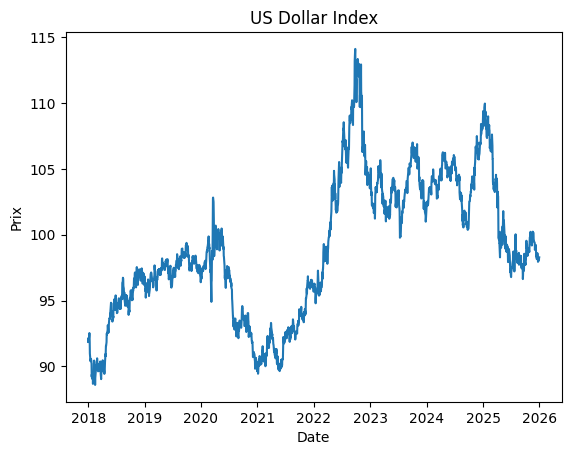

In [ ]:
plt.plot(data.index, data["DXY"])
plt.title("US Dollar Index")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()



**B. Taux d’intérêt à long terme**

La variable US10Y_diff représente la variation du rendement des obligations du Trésor américain à 10 ans. Elle permet de capturer les changements dans les conditions financières et les taux d’intérêt à long terme, qui peuvent avoir un impact sur la valorisation des actions technologiques

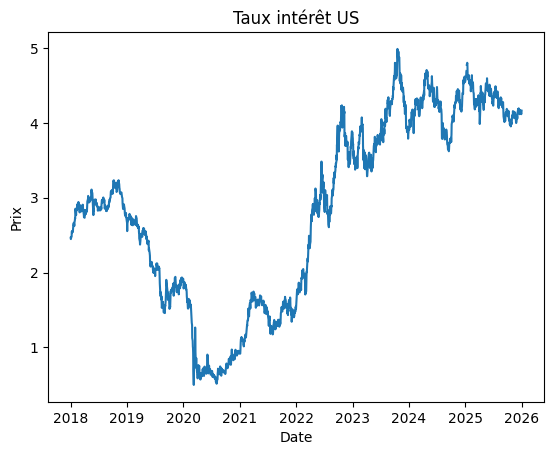

In [ ]:
plt.plot(data.index, data["US10Y"])
plt.title("Taux intérêt US")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

**C. Taux d’intérêt**

Les taux d’intérêt influencent directement la valorisation des actions, en particulier dans le secteur technologique.

Des taux plus élevés, décidés par la Federal Reserve, augmentent le coût du financement et réduisent généralement l’attractivité des actions de croissance, dont la valorisation repose fortement sur les profits futurs. Prendre en compte cette variable permet donc de mieux expliquer les variations du cours de l’action.

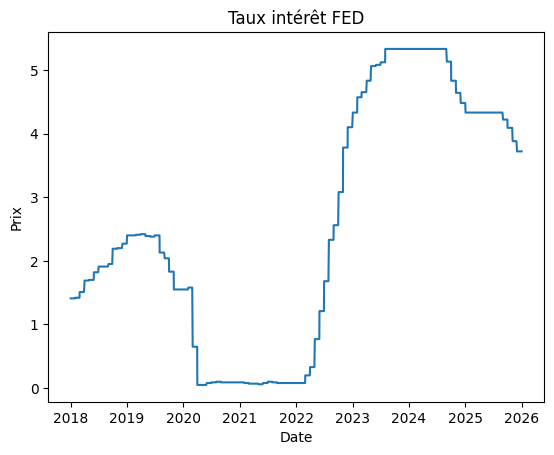

In [ ]:
plt.plot(data.index, data["Taux_FED"])
plt.title("Taux intérêt FED")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

**D. Inflation**

Le taux d’inflation reflète l’environnement macroéconomique dans lequel évoluent les entreprises technologiques et plus largément les marchés financiers.

Par exemple, une hausse de l’inflation peut conduire la Federal Reserve à augmenter ses taux d’intérêt, ce qui renchérit le coût du capital et peut peser sur la valorisation des actions comme NVIDIA.

L’intégrer dans notre analyse permet donc de mieux prendre en compte ces facteurs macroéconomiques susceptibles d’influencer les rendements boursiers.

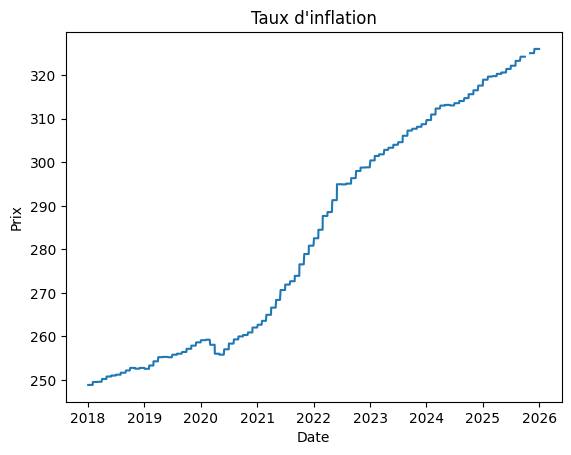

In [ ]:
plt.plot(data.index, data["CPI"])
plt.title("Taux d'inflation")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

**E. GPR Mesure du risque géopolitique**

Construit à partir d’un ensemble d’articles de journaux couvrant les tensions géopolitiques et leurs effets économiques depuis 1900, l’indice de risque géopolitique (GPR) développé par Dario Caldara et Matteo Iacoviello offre aujourd’hui une mesure fiable du contexte géopolitique et de ses conséquences sur l’économie.

À titre d'exemple, l’indice GPR connaît des pics autour des deux guerres mondiales, au début de la guerre de Corée, lors de la crise des missiles de Cuba et après le 11 septembre 2001.

Un niveau élevé de risque géopolitique se traduit par une baisse des investissements, des cours des actions et de l’emploi. Il est également associé à une probabilité plus élevée de crises économiques et à des risques baissiers accrus pour l’économie mondiale.

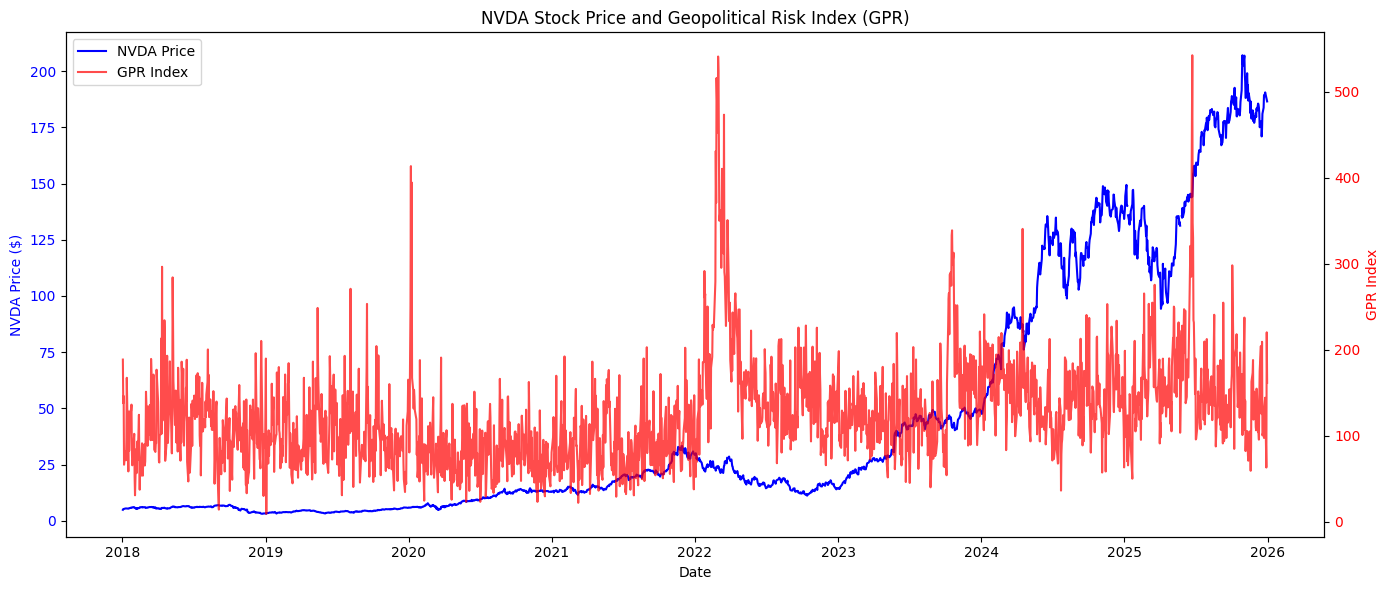

In [ ]:
plt.figure(figsize=(14,6))

# Axe principal : NVDA
ax1 = plt.gca()
ax1.plot(data.index, data['NVDA'], color='blue', label='NVDA Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('NVDA Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Axe secondaire : GPR
ax2 = ax1.twinx()
ax2.plot(data.index, data['GPRD'], color='red', label='GPR Index', alpha=0.7)
ax2.set_ylabel('GPR Index', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Légende combinée
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("NVDA Stock Price and Geopolitical Risk Index (GPR)")
plt.tight_layout()
plt.show()

**F.Guerre commerciale entre la Chine et les États-Unis**

In [ ]:
print(data[['US_Tariffs', 'China_Tariffs']].tail(20))

            US_Tariffs  China_Tariffs
Date                                 
2025-12-03        47.5           31.9
2025-12-04        47.5           31.9
2025-12-05        47.5           31.9
2025-12-08        47.5           31.9
2025-12-09        47.5           31.9
2025-12-10        47.5           31.9
2025-12-11        47.5           31.9
2025-12-12        47.5           31.9
2025-12-15        47.5           31.9
2025-12-16        47.5           31.9
2025-12-17        47.5           31.9
2025-12-18        47.5           31.9
2025-12-19        47.5           31.9
2025-12-22        47.5           31.9
2025-12-23        47.5           31.9
2025-12-24        47.5           31.9
2025-12-26        47.5           31.9
2025-12-29        47.5           31.9
2025-12-30        47.5           31.9
2025-12-31        47.5           31.9


In [ ]:
print(data[['US_Tariffs','China_Tariffs']].head())
print(data[['US_Tariffs','China_Tariffs']].dtypes)

            US_Tariffs  China_Tariffs
Date                                 
2018-01-02         3.2            8.0
2018-01-03         3.2            8.0
2018-01-04         3.2            8.0
2018-01-05         3.2            8.0
2018-01-08         3.2            8.0
US_Tariffs       float64
China_Tariffs    float64
dtype: object


In [ ]:
print(data['US_Tariffs'].apply(type).value_counts())

US_Tariffs
<class 'float'>    2013
Name: count, dtype: int64


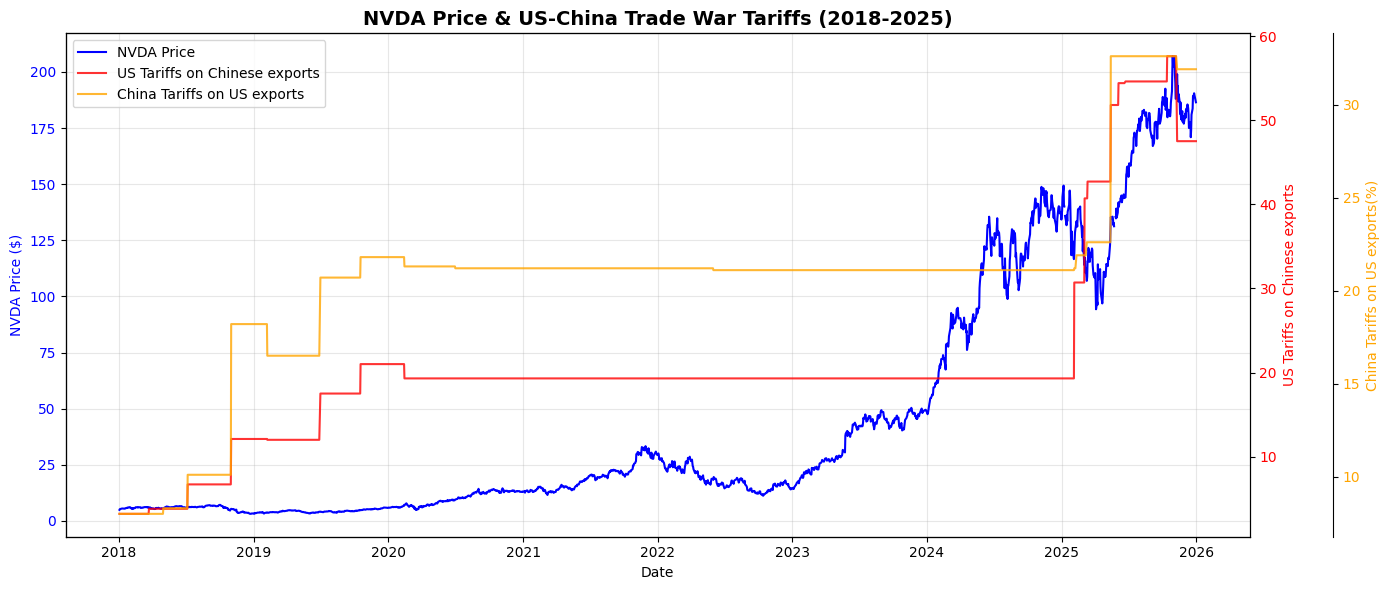

In [ ]:
plt.figure(figsize=(14,6))

# Axe principal : NVDA
ax1 = plt.gca()
ax1.plot(data.index, data['NVDA'], color='blue', label='NVDA Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('NVDA Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Axe secondaire : US_Tariffs
ax2 = ax1.twinx()
ax2.plot(data.index, data['US_Tariffs'], color='red', label='US Tariffs on Chinese exports', alpha=0.8)
ax2.set_ylabel('US Tariffs on Chinese exports', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Axe tertiaire : China_Tariffs
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Décaler à droite
ax3.plot(data.index, data['China_Tariffs'], color='orange', label='China Tariffs on US exports', alpha=0.8)
ax3.set_ylabel('China Tariffs on US exports(%)', color='orange')
ax3.tick_params(axis='y', labelcolor='orange')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc='upper left', fontsize=10)

plt.title("NVDA Price & US-China Trade War Tariffs (2018-2025)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

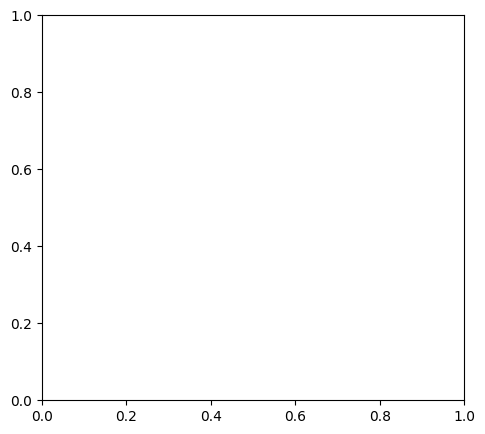

In [ ]:
plt.figure(figsize=(12,5))

# NVDA vs US_Tariffs
plt.subplot(1,2,1)
sns.regplot(x='US_Tariffs', y='NVDA', data=data, color='red', scatter_kws={'alpha':0.6})
plt.title(f'NVDA vs US Tariffs (corr={corr_us:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('US Tariffs (%)')
plt.ylabel('NVDA Price ($)')
plt.grid(True, alpha=0.3)

# NVDA vs China_Tariffs
plt.subplot(1,2,2)
sns.regplot(x='China_Tariffs', y='NVDA', data=data, color='orange', scatter_kws={'alpha':0.6})
plt.title(f'NVDA vs China Tariffs (corr={corr_china:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('China Tariffs (%)')
plt.ylabel('NVDA Price ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**G. Rupture pré/post-COVID-19**

À présent, nous voudrions observer s'il y a eu une rupture liée à la pendémie de COVID-19 et le confinement sanitaire dans le cours de l'action NVDA.

Pour ce faire, nous créons une variable indicatrice (dummy) qui vaut :
- 0 Non - COVID
- 1 période du COVID

Selon les estimations des analystes, le krach boursier déclenché par la pandémie débute en mars 2020. De manière cohérente, la reprise économique marquant la fin de la crise du COVID-19 peut être situées à janvier 2022.

In [ ]:
colors = {0: 'blue', 1: 'red'}

plt.figure(figsize=(14,6))

# Pre-COVID
pre = data[data.index < covid_start]
plt.plot(pre.index, pre['NVDA'], color='blue', label='Pre-COVID')

# COVID
covid = data[(data.index >= covid_start) & (data.index <= covid_end)]
plt.plot(covid.index, covid['NVDA'], color='red', label='COVID')

# Post-COVID
post = data[data.index > covid_end]
plt.plot(post.index, post['NVDA'], color='red')

plt.title("Cours de NVDA selon la période COVID")
plt.xlabel("Date")
plt.ylabel("Prix de clôture (USD)")
plt.legend()
plt.show()

## **VI - Test de stationnarité**

In [ ]:
from statsmodels.tsa.stattools import adfuller

# 1. Sélectionner les colonnes à tester
colonnes_a_tester = ['AMD', 'DXY', 'INTC', 'NVDA', 'SOXX', 'TSMC', 'SP500', 'NASDAQ', 'US10Y', 'VXN', 'GPRD', 'CPI',"Taux_FED"]

print(f"Test ADF sur : {list(colonnes_a_tester)}\n")

# 2. Boucle pour appliquer le test sur chaque variable
for col in colonnes_a_tester:
    # On enlève les NaN pour éviter les erreurs dans le test
    result = adfuller(data[col].dropna())

    print(f"Variable : {col}")
    print(f"Statistique ADF : {result[0]:.4f}")
    print(f"p-value : {result[1]:.4f}")

    # Interprétation du résultat
    if result[1] < 0.05:
        print("Résultat : Stationnaire (Rejet de l'hypothèse nulle)")
    else:
        print("Résultat : Non Stationnaire (Échec du rejet)")
    print("-" * 30)

### **A. Interprétation des résultats**

Toutes les autres variables (**AMD, NVDA, TSMC, SP500, NASDAQ, DXY, INTC, US10Y**) présentent une **p-value élevée** (souvent proche de 1.0, par exemple **NVDA = 0.9973**).

**Résultat : Non stationnaire**

### Interprétation

Ces séries **errent dans le temps** ou présentent une **tendance marquée** (elles augmentent ou diminuent progressivement au fil du temps).

### Risque pour la modélisation

Si ces séries sont utilisées **telles quelles dans une régression**, cela peut conduire à un phénomène appelé **régression spurieuse**.

Dans ce cas, le modèle peut détecter une relation entre les variables **simplement parce qu’elles évoluent toutes dans la même direction au cours du temps**, et non parce qu’il existe une véritable relation économique ou statistique entre elles.

## **VII - Transformation des prix en rendements**

### Pourquoi transformer les prix en rendements ?

Dans les séries financières, les **prix des actifs présentent généralement une tendance** (ils augmentent ou diminuent au fil du temps). Cette tendance rend les séries **non stationnaires**, ce qui peut fausser les analyses statistiques et les modèles de prédiction.

Pour résoudre ce problème, nous transformons les prix en **rendements (returns)** en calculant la variation relative entre deux périodes consécutives.

Cette transformation permet de :

- **Éliminer la tendance** présente dans les séries de prix.
- **Rendre les variables plus comparables**, même si les actifs ont des niveaux de prix très différents (par exemple NVDA vs SP500).
- **Réduire les problèmes d’échelle** entre les variables.
- **Obtenir des séries plus stationnaires**, ce qui est une condition importante pour de nombreux modèles économétriques et de machine learning.

Ainsi, le modèle ne cherche plus à expliquer le **niveau des prix**, mais plutôt les **variations des actifs**, ce qui permet de mieux capturer les relations économiques et les corrélations entre les marchés.

## Cas particulier des variables de taux

Il est important de noter que les **variables de taux d’intérêt**, comme **US10Y** ou **Taux_FED**, ne sont pas transformées en rendements. Contrairement aux actions ou aux indices boursiers, ces variables ne représentent pas des prix d’actifs.

Pour ces variables, il est plus pertinent d’analyser **les variations absolues (différences)** entre deux périodes afin de capturer les changements dans les conditions financières et la politique monétaire.

In [ ]:
# 1. Définir la liste des colonnes financières à transformer
colonnes_financieres = ["NVDA", "SP500", "NASDAQ", "SOXX", "AMD", "TSMC", "INTC", "VXN", "DXY","GPRD","CPI"]

# 2. Créer le nouveau dataframe 'returns' avec le calcul des rendements (pct_change)
returns = data[colonnes_financieres].pct_change()

# 3. Renommer les colonnes en ajoutant le suffixe '_ret' pour plus de clarté
returns = returns.rename(columns={col: f"{col}_ret" for col in colonnes_financieres})

# 4. Joindre les variables macro (CPI, Taux_FED, Event_flag) sans transformation
returns = returns.join(data[["US10Y", "Taux_FED", "COVID_period"]])

# Vérifier les premières lignes du dataset final
print(returns.head())

### **A. Test de stationnarité – prix en rendements**


In [ ]:
from statsmodels.tsa.stattools import adfuller

# 1. Sélectionner les colonnes à tester (toutes sauf les 5 dernières)

colonnes_a_tester = ['NVDA_ret', 'SP500_ret', 'NASDAQ_ret', 'SOXX_ret', 'AMD_ret',
 'TSMC_ret', 'INTC_ret', 'VXN_ret', 'DXY_ret', 'GPRD_ret', 'CPI_ret']

print(f"Test ADF sur : {list(colonnes_a_tester)}\n")

# 2. Boucle pour appliquer le test sur chaque variable
for col in colonnes_a_tester:
    # On enlève les NaN pour éviter les erreurs dans le test
    result = adfuller(returns[col].dropna())

    print(f"Variable : {col}")
    print(f"Statistique ADF : {result[0]:.4f}")
    print(f"p-value : {result[1]:.4f}")

    # Interprétation du résultat
    if result[1] < 0.05:
        print("Résultat : Stationnaire (Rejet de l'hypothèse nulle)")
    else:
        print("Résultat : Non Stationnaire (Échec du rejet)")
    print("-" * 30)

### **B. Analyse des résultats du test ADF**


### Résultats

Les **p-values sont égales à 0.0000 pour toutes les variables**  
(NVDA_ret, AMD_ret, SP500_ret, NASDAQ_ret, etc.).

**Résultat : Stationnaire (rejet de l’hypothèse nulle).**

### Interprétation

La transformation en **rendements** a permis d’éliminer la **tendance** présente dans les séries de prix.

Les données **ne dépendent plus du temps**, ce qui signifie que leurs propriétés statistiques restent relativement stables au cours du temps.

### Implication pour la modélisation

Cette stationnarité est essentielle pour les modèles économétriques et de machine learning, car elle permet au modèle de **capturer les corrélations réelles entre les actifs**, plutôt que de simplement suivre une tendance commune croissante ou décroissante.

In [ ]:
returns.head()

In [ ]:
returns.head()

In [ ]:
dataset = returns.dropna()

In [ ]:
dataset.head()

In [ ]:
dataset.to_excel("dataset_nvda_ml_2.xlsx")

In [ ]:
dataset.reset_index().to_excel("dataset_nvda_ml_2.xlsx", index=False)

### **C. matrice de corrélation**

**Matrice de corrélation** : elle permet d’identifier les relations entre les différentes variables et de détecter d’éventuelles corrélations fortes entre les variables explicatives.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = dataset.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

## **VIII - Feature Engineering**

### **A. Variables retardées (lags)**

Dans les séries temporelles financières, les **valeurs passées des variables peuvent contenir des informations utiles pour prédire les valeurs futures**. Afin de capturer cette dépendance temporelle, nous introduisons des **variables retardées (lags)**.

Dans ce projet, les lags sont appliqués aux **rendements des principaux indices de marché, du secteur des semi-conducteurs et de certaines variables macro-financières**. Ces variables incluent notamment **SP500, NASDAQ, SOXX, AMD, TSMC, INTC, VXN et DXY**, qui représentent respectivement le marché global, le secteur technologique, l'industrie des semi-conducteurs, ainsi que les conditions de volatilité et de change.

L’objectif est de permettre au modèle de capter **les effets retardés et les mécanismes de transmission de l’information entre le marché, le secteur et l’action NVIDIA**.

Les lags sélectionnés sont **1, 2, 3, 5 et 10 jours**, ce qui permet de capturer différentes dynamiques temporelles :

- **1 à 3 jours** : réactions immédiates du marché et ajustements rapides des prix.
- **5 jours** : dynamique hebdomadaire des marchés financiers.
- **10 jours** : effets à plus court/moyen terme liés à la diffusion de l'information sur le marché.

Cette approche permet au modèle d’intégrer **l'information récente du marché tout en évitant l'utilisation d'informations futures**, ce qui permet de prévenir les problèmes de **data leakage**.

In [ ]:
# Définition des lags à créer
lags = [1, 2, 3, 5, 10]

# Variables sur lesquelles nous appliquons les lags
variables_lag = [
    "NVDA_ret", "SP500_ret", "NASDAQ_ret", "SOXX_ret",
    "AMD_ret", "TSMC_ret", "INTC_ret", "VXN_ret", "DXY_ret"
]

# Création d'une copie du dataset
data_lag = dataset.copy()

# Création des variables retardées (lags)
for col in variables_lag:
    for lag in lags:
        data_lag[f"{col}_lag{lag}"] = data_lag[col].shift(lag)

# Suppression des observations avec valeurs manquantes générées par les lags
data_lag = data_lag.dropna()

# Aperçu des premières lignes du dataset
data_lag.head()

### **B. Fenêtres glissantes**

Les **fenêtres glissantes (rolling windows)** permettent de capturer la dynamique récente du marché en calculant des statistiques sur une période donnée.

Dans les séries financières, elles sont souvent utilisées pour mesurer :
- la **tendance récente** à l’aide de moyennes mobiles,
- la **volatilité du marché** à l’aide de l’écart-type des rendements.

Dans cette étude, nous appliquons ces mesures à certaines variables clés du marché :

- **NVDA_ret**, afin de capturer la **volatilité récente de l’action NVIDIA**, qui reflète les changements de risque et d’incertitude autour du titre.
- **SOXX_ret**, car cet ETF représente le **secteur des semi-conducteurs**, auquel NVIDIA appartient. La moyenne mobile et la volatilité du secteur permettent d’identifier les tendances et les conditions récentes du marché des puces.
- **VXN_ret**, qui mesure la **volatilité implicite du NASDAQ**. Cette variable est utilisée comme indicateur du niveau de **stress ou d’incertitude sur les marchés technologiques**.

Ces variables permettent ainsi d’intégrer dans le modèle des informations sur les **conditions récentes du marché, du secteur et du niveau de risque**, qui peuvent influencer l’évolution du rendement de NVIDIA.

In [ ]:
# B. Fenêtres glissantes

# Volatilité et moyennes mobiles sur différentes fenêtres

# NVDA
data_lag["NVDA_ret_vol10"] = data_lag["NVDA_ret"].rolling(window=10).std()
data_lag["NVDA_ret_vol21"] = data_lag["NVDA_ret"].rolling(window=21).std()

# SOXX
data_lag["SOXX_ret_ma10"] = data_lag["SOXX_ret"].rolling(window=10).mean()
data_lag["SOXX_ret_vol10"] = data_lag["SOXX_ret"].rolling(window=10).std()

# VXN
data_lag["VXN_ret_vol10"] = data_lag["VXN_ret"].rolling(window=10).std()

# Suppression des valeurs manquantes générées par les fenêtres glissantes
data_lag = data_lag.dropna()

# Aperçu des données
data_lag.head()

### **C. Différentiels Macro**

Les variables macroéconomiques jouent un rôle important dans l’évolution des marchés financiers, car elles reflètent les **conditions monétaires et économiques globales**.

Dans cette étude, nous utilisons deux transformations liées aux taux d’intérêt. Premièrement, nous calculons la **variation du rendement des obligations américaines à 10 ans (US10Y_diff)**, qui mesure les changements quotidiens dans les taux à long terme. Cette variable permet de capturer les ajustements du marché obligataire face aux nouvelles informations économiques.

Deuxièmement, nous construisons un **spread entre le taux à 10 ans (US10Y) et le taux directeur de la Réserve fédérale (Taux_FED)**. Ce différentiel, souvent appelé **term spread**, est un indicateur largement utilisé pour représenter la **pente de la courbe des taux** et les anticipations des investisseurs concernant la croissance économique et la politique monétaire.

L’intégration de ces variables permet ainsi au modèle de prendre en compte **les conditions macro-financières** qui peuvent influencer les rendements des actifs technologiques comme NVIDIA.

In [ ]:
# C. Différentiels Macro

# Variation du rendement des obligations américaines à 10 ans
data_lag["US10Y_diff"] = data_lag["US10Y"].diff()

# Calcul du spread entre le taux à 10 ans et le taux directeur de la FED
data_lag["US10Y_FED_spread"] = data_lag["US10Y"] - data_lag["Taux_FED"]

# Suppression des valeurs manquantes générées par la différence
data_lag = data_lag.dropna()

data_lag = data_lag.drop(columns=["Taux_FED"])

# Aperçu des nouvelles variables
data_lag[["US10Y", "US10Y_diff", "US10Y_FED_spread"]].head()

### **D- Variables calendaires cycliques**

Dans de nombreux problèmes de prévision en séries temporelles, il est courant d'utiliser des variables calendaires (comme le mois de l'année ou le jour du mois) afin de capturer des **effets saisonniers**. Ces variables sont parfois transformées à l'aide de fonctions **sinus et cosinus** afin de représenter le caractère cyclique du temps et d'éviter des discontinuités artificielles entre des périodes proches, comme décembre et janvier.

Cependant, dans les marchés financiers, et en particulier dans la modélisation des **rendements journaliers des actions**, les effets saisonniers sont généralement beaucoup plus faibles que dans d'autres domaines comme la demande de produits, la consommation d'énergie ou les données climatiques. Les variations des prix des actifs sont principalement influencées par **les conditions du marché, les facteurs macroéconomiques, la volatilité et les dynamiques sectorielles**.

Dans cette étude, nous privilégions donc des variables directement liées aux mécanismes économiques qui influencent les marchés financiers, telles que les **rendements d'actifs liés, les indicateurs de volatilité, les variables macro-financières et les variables retardées (lags)**.

Par conséquent, les transformations cycliques du calendrier (par exemple les encodages sinus et cosinus des mois ou des jours) ne sont pas retenues dans le processus de **feature engineering**, car elles sont peu susceptibles d'apporter une information prédictive significative pour les rendements journaliers de l'action NVIDIA.

In [ ]:
data_lag["day_of_week"] = data_lag.index.dayofweek

In [ ]:
data_lag.to_excel("datasetlag_nvda_ml_2.xlsx")

In [ ]:
data_lag.reset_index().to_excel("datasetlag_nvda_ml_2.xlsx", index=False)

## **IX - Construction et entraînement des modèles**

Après la phase de préparation des données (analyse exploratoire, corrélations et normalisation), nous pouvons maintenant procéder à la construction et à l’entraînement des modèles de machine learning.

L’objectif est de prédire la variable cible **NVDA_ret**, qui représente le rendement de l’action NVIDIA, à partir des différentes variables explicatives liées aux conditions de marché, au secteur technologique et à l’environnement macroéconomique.

Dans cette section, nous allons tester plusieurs modèles :

- **ARIMAX / SARIMAX** : ces modèles de séries temporelles prennent en compte à la fois l’auto-corrélation de la variable cible et l’effet des variables explicatives exogènes, ce qui est pertinent pour capturer les tendances et les cycles du marché.

- **LSTM (Long Short-Term Memory)** : ce réseau de neurones est pertinent pour prédire des rendements financiers qui présentent des patterns complexes et séquentiels.

- **XGBoost** : ce modèle basé sur le gradient boosting est efficace pour capturer les relations non linéaires et les interactions entre les variables explicatives.

Ces modèles seront ensuite évalués à l’aide de différentes métriques afin de comparer leurs performances.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving datasetlag_nvda_ml_2.xlsx to datasetlag_nvda_ml_2.xlsx


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd

data_lag = pd.read_excel("datasetlag_nvda_ml_2.xlsx")

data_lag.head()

,Date,NVDA_ret,SP500_ret,NASDAQ_ret,SOXX_ret,AMD_ret,TSMC_ret,INTC_ret,VXN_ret,DXY_ret,...,DXY_ret_lag5,DXY_ret_lag10,US10Y_diff,US10Y_FED_spread,NVDA_ret_vol10,NVDA_ret_vol21,SOXX_ret_ma10,SOXX_ret_vol10,VXN_ret_vol10,day_of_week
0,2018-02-16,-0.010791,0.000373,-0.002337,-0.003568,-0.030353,-0.000919,-0.007840,-0.018705,0.005757,...,0.002327,0.005977,-0.014,1.457,0.046931,0.034684,0.000431,0.029160,0.256002,4
1,2018-02-20,0.021489,-0.005841,-0.000713,0.017683,0.016921,0.005980,0.016681,0.059140,0.006959,...,-0.002543,0.003924,0.016,1.473,0.034663,0.034581,0.006908,0.024205,0.160288,1
2,2018-02-21,-0.030392,-0.005497,-0.002223,-0.011492,-0.024958,-0.019433,-0.008204,0.037840,0.004012,...,-0.005653,0.000447,0.050,1.523,0.034407,0.035283,0.002139,0.022427,0.150891,2
3,2018-02-22,0.003273,0.000974,-0.001128,-0.002225,0.010239,-0.011658,-0.003047,-0.070253,-0.003663,...,-0.006466,0.007479,-0.026,1.497,0.034338,0.034982,0.004060,0.020958,0.150724,3
4,2018-02-23,0.015611,0.016028,0.017656,0.021408,0.019426,0.035622,0.042140,-0.131516,0.001448,...,-0.005947,-0.000332,-0.046,1.451,0.028262,0.034956,0.010402,0.013864,0.075847,4


In [15]:
data_lag.columns

Index(['Date', 'NVDA_ret', 'SP500_ret', 'NASDAQ_ret', 'SOXX_ret', 'AMD_ret',
       'TSMC_ret', 'INTC_ret', 'VXN_ret', 'DXY_ret', 'GPRD_ret', 'CPI_ret',
       'US10Y', 'COVID_period', 'NVDA_ret_lag1', 'NVDA_ret_lag2',
       'NVDA_ret_lag3', 'NVDA_ret_lag5', 'NVDA_ret_lag10', 'SP500_ret_lag1',
       'SP500_ret_lag2', 'SP500_ret_lag3', 'SP500_ret_lag5', 'SP500_ret_lag10',
       'NASDAQ_ret_lag1', 'NASDAQ_ret_lag2', 'NASDAQ_ret_lag3',
       'NASDAQ_ret_lag5', 'NASDAQ_ret_lag10', 'SOXX_ret_lag1', 'SOXX_ret_lag2',
       'SOXX_ret_lag3', 'SOXX_ret_lag5', 'SOXX_ret_lag10', 'AMD_ret_lag1',
       'AMD_ret_lag2', 'AMD_ret_lag3', 'AMD_ret_lag5', 'AMD_ret_lag10',
       'TSMC_ret_lag1', 'TSMC_ret_lag2', 'TSMC_ret_lag3', 'TSMC_ret_lag5',
       'TSMC_ret_lag10', 'INTC_ret_lag1', 'INTC_ret_lag2', 'INTC_ret_lag3',
       'INTC_ret_lag5', 'INTC_ret_lag10', 'VXN_ret_lag1', 'VXN_ret_lag2',
       'VXN_ret_lag3', 'VXN_ret_lag5', 'VXN_ret_lag10', 'DXY_ret_lag1',
       'DXY_ret_lag2', 'DXY_ret_lag3

In [16]:
data_lag['Date'] = pd.to_datetime(data_lag['Date'])
data_lag = data_lag.set_index('Date')

In [17]:
data_lag.head()

,NVDA_ret,SP500_ret,NASDAQ_ret,SOXX_ret,AMD_ret,TSMC_ret,INTC_ret,VXN_ret,DXY_ret,GPRD_ret,...,DXY_ret_lag5,DXY_ret_lag10,US10Y_diff,US10Y_FED_spread,NVDA_ret_vol10,NVDA_ret_vol21,SOXX_ret_ma10,SOXX_ret_vol10,VXN_ret_vol10,day_of_week
Date,,,,,,,,,,,,,,,,,,,,,
2018-02-16,-0.010791,0.000373,-0.002337,-0.003568,-0.030353,-0.000919,-0.007840,-0.018705,0.005757,-0.237877,...,0.002327,0.005977,-0.014,1.457,0.046931,0.034684,0.000431,0.029160,0.256002,4
2018-02-20,0.021489,-0.005841,-0.000713,0.017683,0.016921,0.005980,0.016681,0.059140,0.006959,0.720256,...,-0.002543,0.003924,0.016,1.473,0.034663,0.034581,0.006908,0.024205,0.160288,1
2018-02-21,-0.030392,-0.005497,-0.002223,-0.011492,-0.024958,-0.019433,-0.008204,0.037840,0.004012,-0.210768,...,-0.005653,0.000447,0.050,1.523,0.034407,0.035283,0.002139,0.022427,0.150891,2
2018-02-22,0.003273,0.000974,-0.001128,-0.002225,0.010239,-0.011658,-0.003047,-0.070253,-0.003663,-0.254160,...,-0.006466,0.007479,-0.026,1.497,0.034338,0.034982,0.004060,0.020958,0.150724,3
2018-02-23,0.015611,0.016028,0.017656,0.021408,0.019426,0.035622,0.042140,-0.131516,0.001448,0.393010,...,-0.005947,-0.000332,-0.046,1.451,0.028262,0.034956,0.010402,0.013864,0.075847,4


In [18]:
data_lag.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1979 entries, 2018-02-16 to 2025-12-31
Data columns (total 66 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   NVDA_ret          1979 non-null   float64
 1   SP500_ret         1979 non-null   float64
 2   NASDAQ_ret        1979 non-null   float64
 3   SOXX_ret          1979 non-null   float64
 4   AMD_ret           1979 non-null   float64
 5   TSMC_ret          1979 non-null   float64
 6   INTC_ret          1979 non-null   float64
 7   VXN_ret           1979 non-null   float64
 8   DXY_ret           1979 non-null   float64
 9   GPRD_ret          1979 non-null   float64
 10  CPI_ret           1979 non-null   float64
 11  US10Y             1979 non-null   float64
 12  COVID_period      1979 non-null   int64  
 13  NVDA_ret_lag1     1979 non-null   float64
 14  NVDA_ret_lag2     1979 non-null   float64
 15  NVDA_ret_lag3     1979 non-null   float64
 16  NVDA_ret_lag5     1979 n

## **1. Modèle : ARIMAX / SARIMAX**

### **Analyse ACF et PACF**

Nous analysons les fonctions d'autocorrélation (ACF) et d'autocorrélation partielle (PACF) des rendements de NVIDIA afin d’identifier une éventuelle dépendance temporelle dans la série.

La **ACF** mesure la corrélation entre la série et ses retards, tandis que la **PACF** mesure cette corrélation en contrôlant l’effet des retards intermédiaires.

D’après les graphiques, la plupart des coefficients restent à l’intérieur des bandes de confiance. Cela suggère l’absence d’autocorrélation significative : les rendements se comportent approximativement comme un bruit blanc.


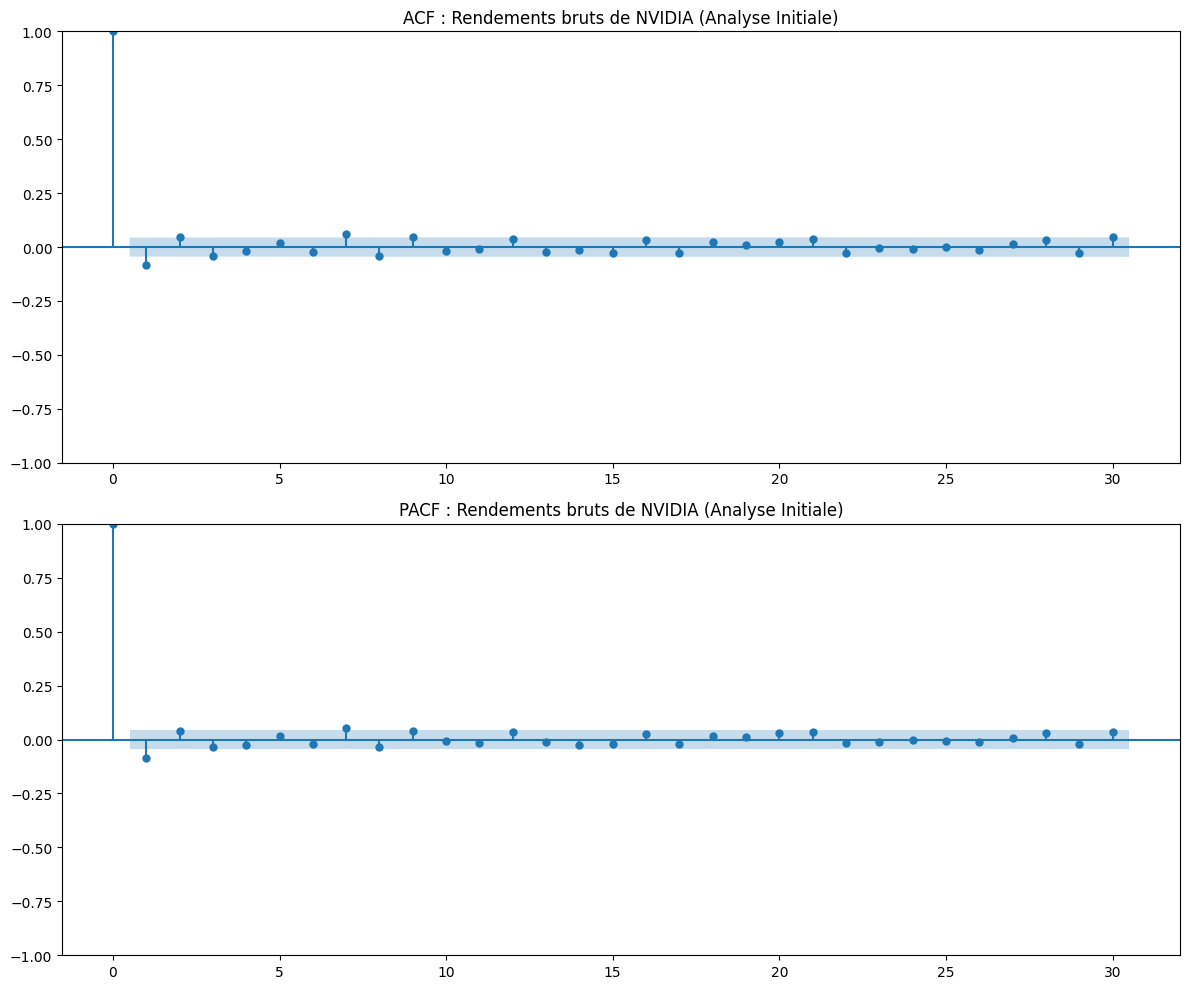

In [19]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# On analyse les rendements bruts de NVIDIA
serie_rendements = data_lag['NVDA_ret']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF de la série brute
sm.graphics.tsa.plot_acf(serie_rendements, lags=30, ax=ax1)
ax1.set_title('ACF : Rendements bruts de NVIDIA (Analyse Initiale)')

# PACF de la série brute
sm.graphics.tsa.plot_pacf(serie_rendements, lags=30, ax=ax2)
ax2.set_title('PACF : Rendements bruts de NVIDIA (Analyse Initiale)')

plt.tight_layout()
plt.show()

### **Estimation et évaluation du modèle ARIMAX**

Dans cette section, nous estimons un modèle ARIMAX(1,0,1) afin de modéliser les rendements de NVIDIA en intégrant des variables explicatives externes. Les données sont d’abord divisées en échantillon d’entraînement (80%) et échantillon de test (20%) afin d’évaluer la capacité prédictive du modèle.

Après l’estimation du modèle, nous générons des prédictions sur l’échantillon de test et évaluons la performance à l’aide de deux indicateurs : MAE (Mean Absolute Error) et R².



In [33]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Définir la cible et les variables exogènes (X)
# On utilise les données non scalées pour l'interprétation statistique
exog = data_lag.drop(columns=['NVDA_ret'])
endog = data_lag['NVDA_ret']

# Division Train/Test
split = int(len(data_lag) * 0.8)
train_endog, test_endog = endog[:split], endog[split:]
train_exog, test_exog = exog[:split], exog[split:]

# 2. Définition du modèle (ordre p, d, q)
# (1,0,1) est une base classique pour les rendements boursiers
model_sarimax = sm.tsa.statespace.SARIMAX(
    train_endog,
    exog=train_exog,
    order=(1, 0, 1),              # ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0)    # Pas de saisonnalité pour commencer
)

results = model_sarimax.fit(disp=False)

# 3. Prédictions
preds_sarimax = results.predict(start=split, end=len(data_lag)-1, exog=test_exog)

# 4. Métriques
print(f"--- Performance ARIMAX ---")
print(f"MAE  : {mean_absolute_error(test_endog, preds_sarimax):.5f}")
print(f"R2   : {r2_score(test_endog, preds_sarimax):.5f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


--- Performance ARIMAX ---
MAE  : 0.01476
R2   : 0.62304


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### **Interprétation des résultats**

Les résultats montrent un MAE faible, ce qui signifie que les prédictions ne s’écartent pas fortement des valeurs réelles. Cependant, le R² est proche de zéro, indiquant que le modèle explique très peu la variabilité des rendements. Ce résultat est courant dans les séries financières, car les rendements boursiers sont généralement très difficiles à prédire et présentent un comportement proche du bruit blanc.

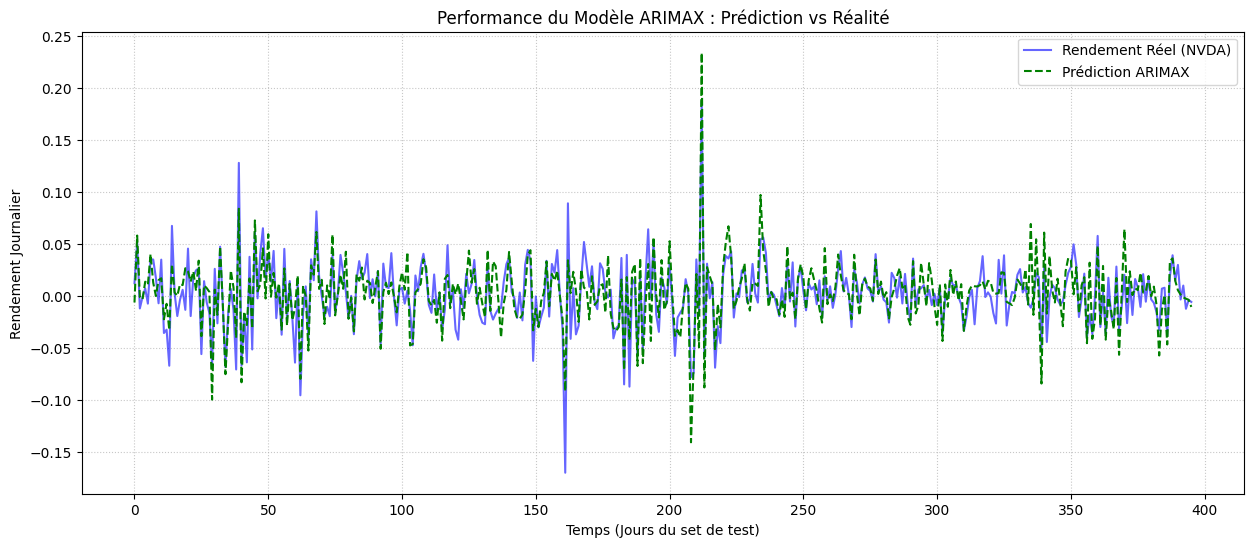

In [21]:
import matplotlib.pyplot as plt

# 1. Création du graphique ARIMAX
plt.figure(figsize=(15, 6))

# On utilise test_endog qui contient les vraies valeurs (Y réel)
plt.plot(test_endog.values, color='blue', label='Rendement Réel (NVDA)', alpha=0.6)

# On affiche les prédictions ARIMAX
plt.plot(preds_sarimax.values, color='green', label='Prédiction ARIMAX', linestyle='--')

plt.title('Performance du Modèle ARIMAX : Prédiction vs Réalité')
plt.xlabel('Temps (Jours du set de test)')
plt.ylabel('Rendement Journalier')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### **Comparaison entre les prédictions et les valeurs réelles**

Le graphique compare les **rendements réels de NVIDIA** avec les **prédictions du modèle ARIMAX** sur l’échantillon de test.

On observe que les prédictions suivent globalement la dynamique générale de la série, mais elles restent plus **lissées** et ne capturent pas toujours les variations extrêmes des rendements. Les pics positifs ou négatifs importants sont parfois sous-estimés par le modèle.

Cela confirme les résultats obtenus avec les métriques précédentes : le modèle reproduit partiellement le comportement moyen de la série, mais il reste **limité dans sa capacité à prédire précisément les fluctuations journalières**, ce qui est fréquent dans les séries de rendements financiers.


## **2. Modèle: LSTM**

Dans cette section, nous implémentons un modèle **LSTM (Long Short-Term Memory)** afin de capturer les dépendances temporelles potentielles dans les rendements de NVIDIA.

Tout d’abord, nous séparons les **variables explicatives (X)** et la **variable cible (y)** correspondant aux rendements de NVIDIA (`NVDA_ret`). Afin d’améliorer la stabilité de l’entraînement du réseau de neurones, les données sont **normalisées entre 0 et 1** à l’aide de `MinMaxScaler`.

Les données sont ensuite **restructurées au format requis par les réseaux LSTM**, c’est-à-dire sous la forme *(échantillons, pas de temps, variables)*. Dans notre cas, les variables retardées déjà présentes dans le dataset sont utilisées comme caractéristiques temporelles.

Nous divisons ensuite les données en **échantillon d’entraînement (80%)** et **échantillon de test (20%)** pour évaluer la performance du modèle.

Le réseau de neurones est constitué de :

* **deux couches LSTM** permettant de capter les relations temporelles dans la série,
* des **couches Dropout** pour réduire le risque de surapprentissage,
* des **couches Dense** pour produire la prédiction finale.

Le modèle est entraîné avec l’optimiseur **Adam** et la fonction de perte **Mean Squared Error (MSE)**. L’entraînement est effectué sur plusieurs époques en utilisant l’échantillon de test comme **validation** afin de suivre la performance du modèle pendant l’apprentissage.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
# Définir la cible (y) et les prédicteurs (X)
y = data_lag[['NVDA_ret']].values
X = data_lag.drop(columns=['NVDA_ret']).values

In [24]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [25]:
# Normalisation (0 à 1)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Reshape pour LSTM [échantillons, pas de temps, caractéristiques]
# On utilise 1 pas de temps car tes lags sont déjà en colonnes
X_final = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Séparation Temporelle (80% Train / 20% Test)
split = int(len(X_final) * 0.8)
X_train, X_test = X_final[:split], X_final[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

model = Sequential([
    # Première couche LSTM
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    # Deuxième couche LSTM
    LSTM(50, return_sequences=False),
    Dropout(0.2),

    # Couches denses pour la décision finale
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

print("Entraînement en cours...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Entraînement en cours...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0335 - val_loss: 0.0062
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0075 - val_loss: 0.0050
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0066 - val_loss: 0.0047
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - val_loss: 0.0042
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052 - val_loss: 0.0035
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - val_loss: 0.0025
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_loss: 0.00

In [26]:
# Prédiction sur le set de test
predictions_scaled = model.predict(X_test)

# Inversion de la normalisation pour retrouver les rendements réels
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Calcul des scores
mae = mean_absolute_error(y_test_real, predictions)
rmse = np.sqrt(mean_squared_error(y_test_real, predictions))
r2 = r2_score(y_test_real, predictions)

print(f"\n--- RÉSULTATS LSTM ---")
print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R2   : {r2:.5f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

--- RÉSULTATS LSTM ---
MAE  : 0.01534
RMSE : 0.02036
R2   : 0.58933


### **Interprétation des résultats du modèle LSTM**

Après l’entraînement du modèle LSTM, nous évaluons sa performance sur l’échantillon de test à l’aide de trois indicateurs : **MAE**, **RMSE** et **R²**.

Le **MAE (0.01534)** indique que l’erreur moyenne absolue entre les rendements réels et les prédictions est relativement faible. Cela signifie que, en moyenne, les prédictions du modèle restent proches des valeurs observées.

Le **RMSE (0.02036)** confirme ce résultat en montrant que les erreurs importantes restent limitées.

Le **R² (0.58933)** indique que le modèle explique environ **59 % de la variance des rendements** sur l’échantillon de test. Ce résultat suggère que le modèle LSTM capture une partie significative de la dynamique des rendements.

Globalement, ces résultats indiquent que le modèle LSTM présente une **capacité prédictive relativement satisfaisante**, notamment comparé aux modèles linéaires classiques souvent utilisés pour les séries financières.



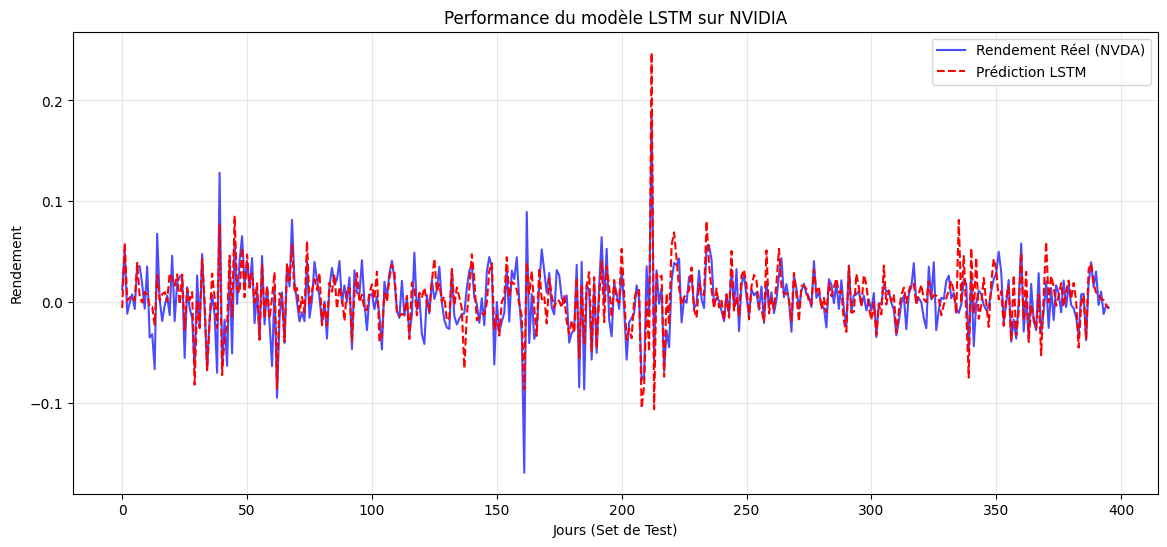

In [27]:

#  VISUALISATION
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, color='blue', label='Rendement Réel (NVDA)', alpha=0.7)
plt.plot(predictions, color='red', label='Prédiction LSTM', linestyle='--')
plt.title('Performance du modèle LSTM sur NVIDIA')
plt.xlabel('Jours (Set de Test)')
plt.ylabel('Rendement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Comparaison entre les rendements réels et les prédictions du modèle LSTM**

Le graphique compare les **rendements réels de NVIDIA** (ligne bleue) avec les **prédictions du modèle LSTM** (ligne rouge en pointillés) sur l’échantillon de test.

On observe que les prédictions suivent globalement la dynamique de la série réelle. Le modèle parvient à reproduire une grande partie des fluctuations des rendements, ce qui confirme les résultats obtenus avec les métriques d’évaluation.

Cependant, certaines variations extrêmes ne sont pas parfaitement capturées par le modèle. Les pics très importants sont parfois **surestimés ou sous-estimés**, ce qui est fréquent dans la prédiction des rendements financiers.

Dans l’ensemble, le modèle LSTM semble capable de **reproduire la structure générale des rendements**, tout en restant limité pour anticiper parfaitement les mouvements les plus volatils du marché.


## **3. Modèle: XGBoost**

Dans cette section, nous utilisons le modèle **XGBoost (Extreme Gradient Boosting)** afin de prédire les rendements journaliers de l'action **NVIDIA**.

XGBoost est un algorithme d'apprentissage automatique basé sur des **arbres de décision boostés**, reconnu pour sa robustesse et ses performances élevées dans les problèmes de **données tabulaires** ainsi que dans les tâches de **régression et de classification**.

Contrairement aux modèles linéaires traditionnels, XGBoost est capable de capturer **des relations non linéaires et des interactions complexes** entre les variables explicatives et la variable cible. Cela est particulièrement utile dans les marchés financiers, où les relations entre les variables macroéconomiques, sectorielles et de volatilité peuvent être **instables et difficiles à modéliser avec des approches linéaires classiques**.


Dans ce projet, le modèle est entraîné pour prédire le **rendement journalier de NVIDIA (NVDA_ret)** en utilisant un ensemble de variables explicatives comprenant :

- les rendements des indices de marché (SP500, NASDAQ),
- les rendements d'entreprises du secteur des semi-conducteurs (AMD, TSMC, INTC),
- des indicateurs de volatilité (VXN),
- des variables macro-financières,
- ainsi que des variables retardées (lags) et des statistiques calculées à partir de fenêtres glissantes.


Les données financières possèdent une **structure temporelle**, ce qui signifie que les observations futures ne doivent jamais être utilisées pour entraîner le modèle.

Afin de respecter cette contrainte, nous utilisons une **validation croisée adaptée aux séries temporelles (*Time Series Cross-Validation*)**.

Cette méthode consiste à :

1. entraîner le modèle sur des **périodes passées**
2. tester le modèle sur des **périodes plus récentes**
3. répéter ce processus sur plusieurs **fenêtres temporelles**

Les données sont ainsi divisées en plusieurs **folds chronologiques**, où chaque itération entraîne le modèle sur un ensemble de données historiques et l'évalue sur une période ultérieure.

Cette approche permet :

- d'éviter toute **fuite d'information (*data leakage*)**
- de tester la **stabilité du modèle dans différentes conditions de marché**

Une fois le modèle entraîné, ses performances seront évaluées à l'aide de plusieurs métriques, notamment **le Mean Squared Error (MSE), le Mean Absolute Error (MAE) et le coefficient de détermination (R²)**.

In [28]:
pip install --upgrade xgboost

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------
# SÉPARATION X ET y
# -------------------------------

X = data_lag.drop(columns=['NVDA_ret'])
y = data_lag['NVDA_ret']

# -------------------------------
# TIME SERIES CROSS VALIDATION
# -------------------------------

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

print("Début de la Cross-Validation...\n")

for fold, (train_index, test_index) in enumerate(tscv.split(X)):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # -------------------------------
    # MODÈLE XGBOOST
    # -------------------------------

    model_xgb = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    print(f"Entraînement Fold {fold+1}...")

    model_xgb.fit(X_train, y_train)

    # -------------------------------
    # PRÉDICTIONS
    # -------------------------------

    preds = model_xgb.predict(X_test)

    # -------------------------------
    # MÉTRIQUES
    # -------------------------------

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold+1} Results")
    print(f"MAE  : {mae:.5f}")
    print(f"RMSE : {rmse:.5f}")
    print(f"R2   : {r2:.5f}\n")


# -------------------------------
# RÉSULTATS MOYENS
# -------------------------------

print("------ CROSS VALIDATION RESULTS ------")
print(f"MAE moyen  : {np.mean(mae_scores):.5f}")
print(f"RMSE moyen : {np.mean(rmse_scores):.5f}")
print(f"R2 moyen   : {np.mean(r2_scores):.5f}")


Début de la Cross-Validation...

Entraînement Fold 1...
Fold 1 Results
MAE  : 0.01340
RMSE : 0.02031
R2   : 0.63407

Entraînement Fold 2...
Fold 2 Results
MAE  : 0.01280
RMSE : 0.01726
R2   : 0.61167

Entraînement Fold 3...
Fold 3 Results
MAE  : 0.01179
RMSE : 0.01632
R2   : 0.81474

Entraînement Fold 4...
Fold 4 Results
MAE  : 0.01502
RMSE : 0.02120
R2   : 0.60344

Entraînement Fold 5...
Fold 5 Results
MAE  : 0.01384
RMSE : 0.01905
R2   : 0.58779

------ CROSS VALIDATION RESULTS ------
MAE moyen  : 0.01337
RMSE moyen : 0.01883
R2 moyen   : 0.65034


## **Interprétation des résultats de la validation croisée**

La validation croisée adaptée aux séries temporelles permet d'évaluer la capacité du modèle à généraliser ses prédictions sur différentes périodes du marché. Dans chaque *fold*, le modèle est entraîné sur un ensemble de données historiques et testé sur une période plus récente.

### Résultats globaux

Les résultats obtenus pour les cinq folds montrent des performances relativement stables du modèle :

- **MAE moyen : 0.01337**
- **RMSE moyen : 0.01883**
- **R² moyen : 0.65034**

Le **Mean Absolute Error (MAE)** indique que l'erreur moyenne de prédiction est d'environ **1.3 % du rendement journalier**, ce qui suggère que les prédictions du modèle restent relativement proches des valeurs observées.

Le **Root Mean Squared Error (RMSE)** est légèrement plus élevé, car cette métrique pénalise davantage les erreurs importantes. Cela indique que, bien que les erreurs moyennes soient faibles, certains jours peuvent présenter des écarts de prédiction plus importants, ce qui est fréquent dans les séries financières caractérisées par une forte volatilité.

### Capacité explicative du modèle

Le **R² moyen d'environ 0.65** suggère que le modèle est capable d'expliquer près de **65 % de la variabilité des rendements observés** dans les données utilisées. Ce résultat indique que le modèle capture une partie importante des relations entre les variables explicatives (indices de marché, entreprises du secteur des semi-conducteurs, indicateurs de volatilité, etc.) et le rendement de l'action NVIDIA.

### Stabilité des performances

Les résultats restent relativement cohérents entre les différents folds, avec des valeurs de **R² comprises entre environ 0.59 et 0.81**. Cette variation peut refléter des différences dans les conditions de marché entre les périodes analysées. Par exemple, certaines périodes peuvent présenter des dynamiques plus prévisibles, tandis que d'autres peuvent être caractérisées par une volatilité plus élevée ou des changements structurels dans le marché.

### Conclusion

Dans l'ensemble, les résultats de la validation croisée suggèrent que le modèle XGBoost présente **une capacité prédictive relativement stable et des erreurs de prédiction modérées** sur les différentes périodes analysées. Ces résultats indiquent que le modèle parvient à capturer certaines dynamiques du marché affectant le rendement de l'action NVIDIA, tout en restant relativement robuste face aux variations temporelles des données financières.

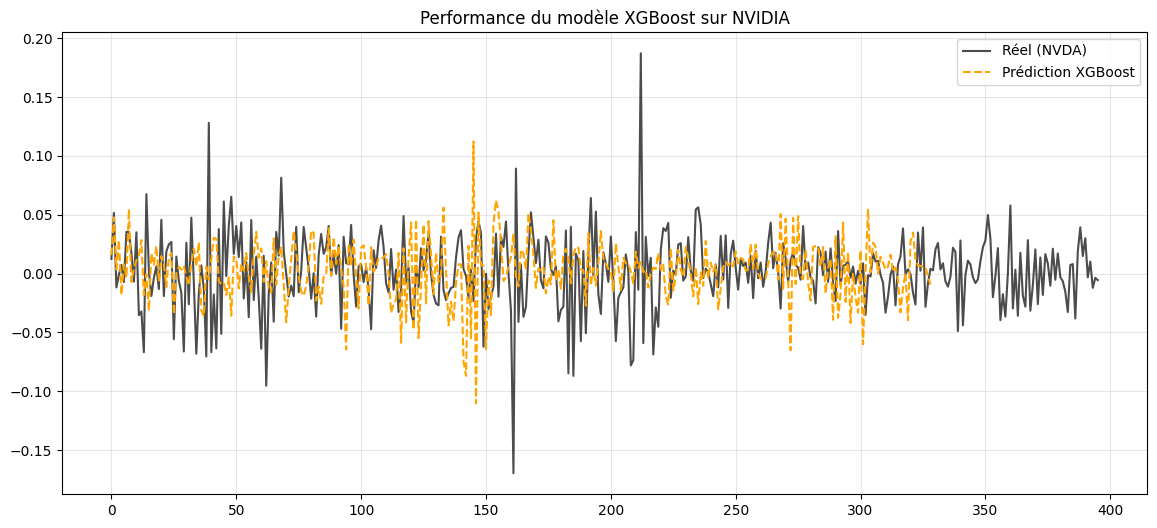

In [32]:
# Graphique 1 : Performance (Réel vs Prédiction)
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, color='black', label='Réel (NVDA)', alpha=0.7)
plt.plot(preds, color='orange', label='Prédiction XGBoost', linestyle='--')
plt.title('Performance du modèle XGBoost sur NVIDIA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Graphique 2 : Importance des variables (Feature Importance)
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, max_num_features=10, importance_type='gain', ax=plt.gca())
plt.title('Top 10 des variables les plus influentes (XGBoost)')
plt.show()

## **Interprétation de l'importance des variables**

Le graphique ci-dessus présente les **10 variables les plus influentes** dans les prédictions du modèle XGBoost. L'importance est mesurée à l'aide du critère **"gain"**, qui représente l'amélioration moyenne de la performance du modèle apportée par chaque variable lors de la construction des arbres de décision.

### Variables les plus importantes

La variable la plus influente est **SOXX_ret**, qui correspond au rendement de l'indice **PHLX Semiconductor (SOXX)**. Cette importance élevée est cohérente d'un point de vue économique, car NVIDIA fait partie du secteur des semi-conducteurs et son comportement boursier est fortement lié aux dynamiques globales de ce secteur.

La deuxième variable la plus importante est **NASDAQ_ret**. Cela est également logique puisque NVIDIA est une entreprise technologique cotée au NASDAQ, et ses performances boursières sont souvent corrélées aux mouvements de cet indice.

Ensuite, on observe que les rendements d'autres entreprises du secteur des semi-conducteurs, comme **AMD_ret**, **TSMC_ret** et **INTC_ret**, apparaissent également parmi les variables importantes. Cela suggère que les mouvements des entreprises comparables dans le même secteur peuvent fournir des informations utiles pour anticiper les variations du rendement de NVIDIA.

### Variables liées à la dynamique temporelle

Certaines variables dérivées des séries temporelles apparaissent également dans les variables importantes :

- **NVDA_ret_vol10**, qui mesure la volatilité récente du rendement de NVIDIA,
- **NVDA_ret_vol21**, qui capture la volatilité sur une fenêtre temporelle plus longue,
- **AMD_ret_lag2**, qui représente un rendement retardé d'une autre entreprise du secteur.

Ces variables permettent au modèle de prendre en compte **les dynamiques temporelles et les effets de volatilité**, qui jouent souvent un rôle important dans les marchés financiers.

### Variables macro-financières

Enfin, des variables comme **VXN_ret_vol10** (volatilité du NASDAQ) et **COVID_period** apparaissent également dans le classement. Bien que leur importance soit plus faible, elles peuvent capturer **des effets de marché plus larges ou des chocs macroéconomiques spécifiques**.

### Conclusion

Dans l'ensemble, les résultats du graphique d'importance des variables suggèrent que les prédictions du modèle reposent principalement sur :

- les **dynamiques sectorielles des semi-conducteurs**,  
- les **mouvements des indices de marché technologiques**,  
- ainsi que sur certaines **caractéristiques temporelles des rendements et de la volatilité**.

Cela indique que le modèle parvient à identifier des relations économiquement plausibles entre les variables explicatives et le rendement de l'action NVIDIA.